In [5]:
import sleap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from python_tsp.distances import euclidean_distance_matrix
from python_tsp.heuristics import solve_tsp_local_search
import time

import sys
sys.path.append('..')
from python import *
sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [3]:
reencoded_10min_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/predictions/flowmax-tracking/reencoded_10min_t3.slp'
reencoded_10min_labels = sleap.load_file(reencoded_10min_path)
frame_cnt, x, y = reencoded_10min_labels.video.shape[:3]
print(reencoded_10min_labels)

Labels(labeled_frames=90003, videos=1, skeletons=1, tracks=18)


In [11]:
from python.polygon_based_correction import *
methods = [(f'poly_{i}', eval(f'poly_{i}')) for i in range(1, 4)]

number of frames without instances: 36276


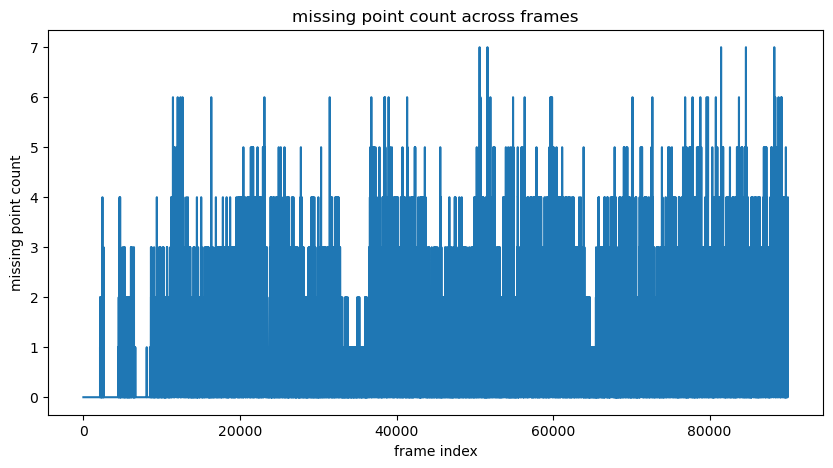

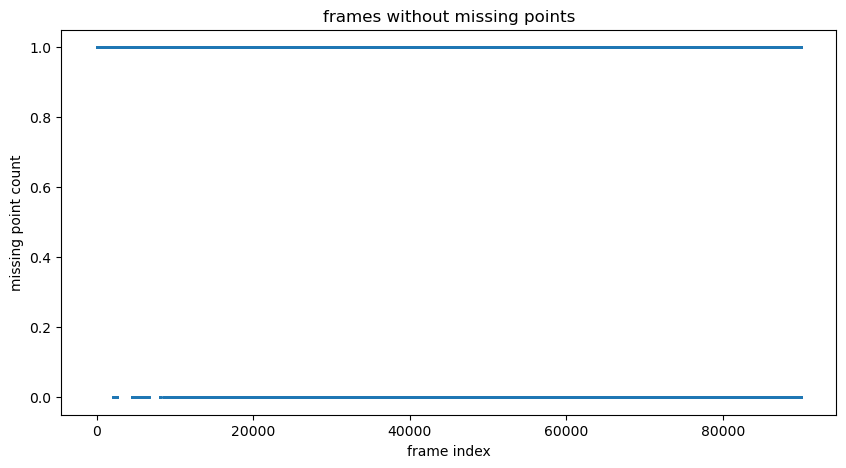

In [21]:
missing_point_cnt = np.zeros(frame_cnt - 1)
for lf in reencoded_10min_labels.labeled_frames[1:]:
    missing_point_cnt[lf.frame_idx - 1] = 17 - len(lf.instances)
print(f'number of frames without instances: {np.sum(missing_point_cnt == 0)}')
plt.figure(figsize=(10, 5))
plt.title('missing point count across frames')
plt.xlabel('frame index')
plt.ylabel('missing point count')
plt.plot(missing_point_cnt)
plt.show()

frames_without_missing_points = missing_point_cnt == 0
plt.figure(figsize=(10, 5))
plt.title('frames without missing points')
plt.xlabel('frame index')
plt.ylabel('missing point count')
# plt.plot(frames_without_missing_points)
plt.scatter(np.arange(len(frames_without_missing_points)), frames_without_missing_points, s=1)
plt.show()